In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
device = "cpu"


In [11]:
transform = transforms.Compose([
    transforms.Resize((8, 8)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1)
])

dataset = datasets.MNIST(root="./data", download=True, transform=transform)

zero_data = [(img, label) for img, label in dataset if label == 0]
loader = DataLoader(zero_data, batch_size=64, shuffle=True)

In [12]:

T = 50

beta = torch.linspace(1e-4, 0.02, T)
alpha = 1 - beta
alpha_hat = torch.cumprod(alpha, dim=0)



In [13]:

def add_noise(x, t):
    sqrt_alpha_hat = torch.sqrt(alpha_hat[t])[:, None, None, None]
    sqrt_one_minus = torch.sqrt(1 - alpha_hat[t])[:, None, None, None]

    noise = torch.randn_like(x)
    return sqrt_alpha_hat * x + sqrt_one_minus * noise, noise

class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.linear = nn.Sequential(
            nn.Linear(1, dim),
            nn.ReLU(),
            nn.Linear(dim, dim)
        )

    def forward(self, t):
        return self.linear(t.unsqueeze(-1).float())

class BetterUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.time_mlp = TimeEmbedding(32)

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.conv3 = nn.Conv2d(64, 32, 3, padding=1)
        self.out = nn.Conv2d(32, 1, 1)

        self.relu = nn.ReLU()

    def forward(self, x, t):
        t_embed = self.time_mlp(t)[:, :, None, None]

        x = self.relu(self.conv1(x))
        x = x + t_embed

        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))

        return self.out(x)


In [14]:

import time

start_time = time.time()

model = BetterUNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epochs = 5  # slightly more for better result

for epoch in range(epochs):
    for x, _ in loader:
        x = x.to(device)

        t = torch.randint(0, T, (x.size(0),), device=device)

        x_noisy, noise = add_noise(x, t)

        pred = model(x_noisy, t)
        loss = loss_fn(pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


end_time = time.time()

print(f"\nTotal Training Time: {end_time - start_time:.2f} seconds")


Epoch 1, Loss: 0.8642
Epoch 2, Loss: 0.5415
Epoch 3, Loss: 0.3930
Epoch 4, Loss: 0.3150
Epoch 5, Loss: 0.2563


In [15]:

@torch.no_grad()
def sample(model, n=5):
    model.eval()
    x = torch.randn((n, 1, 8, 8)).to(device)

    for t in reversed(range(T)):
        t_tensor = torch.full((n,), t, device=device, dtype=torch.long)

        pred_noise = model(x, t_tensor)

        a = alpha[t]
        a_hat = alpha_hat[t]
        b = beta[t]

        noise = torch.randn_like(x) if t > 0 else torch.zeros_like(x)

        x = (1 / torch.sqrt(a)) * (
            x - ((1 - a) / torch.sqrt(1 - a_hat)) * pred_noise
        ) + torch.sqrt(b) * noise

    return x


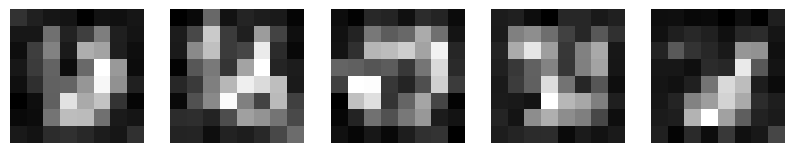

In [16]:
samples = sample(model, n=5)

fig, axes = plt.subplots(1, 5, figsize=(10,2))
for i in range(5):
    img = samples[i].squeeze().cpu().numpy()
    img = (img + 1) / 2
    axes[i].imshow(img, cmap='gray')
    axes[i].axis("off")

plt.show()


# Now we save and load it back again

In [17]:
# 1) save
torch.save({
    "model_state_dict": model.state_dict(),
    "T": T
}, "diffusion_model.pth")

print("Model saved!")


Model saved!


In [18]:
import torch

device = "cpu"  # or "cuda"

# Recreate model
model = BetterUNet().to(device)

# Load checkpoint
checkpoint = torch.load("diffusion_model.pth", map_location=device)

# Load weights
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Restore T
T = checkpoint["T"]


In [19]:
# 3) RECREATE NOISE SCHEDULE (VERY IMPORTANT)
beta = torch.linspace(1e-4, 0.02, T).to(device)
alpha = 1 - beta
alpha_hat = torch.cumprod(alpha, dim=0)


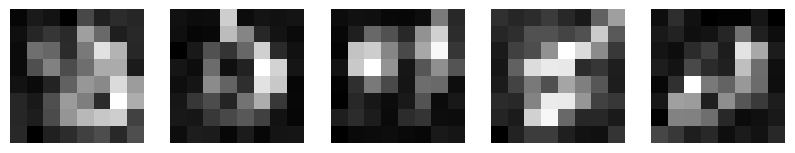

In [20]:
# 4. GENERATE SAMPLES (same function as before)
@torch.no_grad()
def sample(model, n=5):
    model.eval()
    x = torch.randn((n, 1, 8, 8)).to(device)

    for t in reversed(range(T)):
        t_tensor = torch.full((n,), t, device=device, dtype=torch.long)

        pred_noise = model(x, t_tensor)

        a = alpha[t]
        a_hat = alpha_hat[t]
        b = beta[t]

        noise = torch.randn_like(x) if t > 0 else torch.zeros_like(x)

        x = (1 / torch.sqrt(a)) * (
            x - ((1 - a) / torch.sqrt(1 - a_hat)) * pred_noise
        ) + torch.sqrt(b) * noise

    return x


samples = sample(model, n=5)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(10,2))
for i in range(5):
    img = samples[i].squeeze().cpu().numpy()
    img = (img + 1) / 2
    axes[i].imshow(img, cmap='gray')
    axes[i].axis("off")

plt.show()
